Optimal Model with MediaPipe Hand Landmarking applied as preprocessing.

In [ ]:
# Mount Google Drive
import os
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# Set up dataset path
os.chdir("drive/My Drive/")
spreadsheet_path = "Auslan Static Dataset Breakdown"
dataset_path = "AuslanStaticData"

Mounted at /content/drive


In [ ]:
from google.colab import auth
auth.authenticate_user()

import gspread
from google.auth import default
creds, _ = default()

# Authorise sheets access
gc = gspread.authorize(creds)

In [ ]:
import pandas as pd

worksheet = gc.open('Auslan Static Dataset Breakdown').sheet1

# Get all values from the worksheet
rows = worksheet.get_all_values()

# Convert to DataFrame with first row as column names
spreadsheet = pd.DataFrame(rows[1:], columns=rows[0])

print(spreadsheet)

     ID Subject         Date            Device        Filename Class Lighting  \
0     0    Nick   Feb 8 2025  Dell XPS 15 9050    Nick_0_1.jpg     0  Natural   
1     1    Nick   Feb 8 2025  Dell XPS 15 9050    Nick_1_1.jpg     1  Natural   
2     2    Nick   Feb 8 2025  Dell XPS 15 9050    Nick_2_1.jpg     2  Natural   
3     3    Nick   Feb 8 2025  Dell XPS 15 9050    Nick_3_1.jpg     3  Natural   
4     4    Nick   Feb 8 2025  Dell XPS 15 9050    Nick_4_1.jpg     4  Natural   
...  ..     ...          ...               ...             ...   ...      ...   
4729       Nick  Apr 29 2025         iPhone 12  Nick_u_114.JPG     u  Natural   
4730       Nick  Apr 29 2025         iPhone 12  Nick_u_115.JPG     u  Natural   
4731       Nick  Apr 29 2025         iPhone 12  Nick_u_116.JPG     u  Natural   
4732       Nick  Apr 29 2025         iPhone 12  Nick_u_117.JPG     u  Natural   
4733       Nick  Apr 29 2025         iPhone 12  Nick_u_118.JPG     u  Natural   

     Light level           

In [ ]:
# Get list of files
file_list = os.listdir(dataset_path)

# Convert to DataFrame
drive_files = pd.DataFrame(file_list, columns=['Filename'])

set1 = set(drive_files['Filename'])
set2 = set(spreadsheet["Filename"])

# Find missing files
missing_in_df2 = set1 - set2  # Files in df1 but not in df2
missing_in_df1 = set2 - set1  # Files in df2 but not in df1

print("Files missing in Spreadsheet:", missing_in_df2)
print("Files missing in Drive folder:", missing_in_df1)

print(set1)
print(set2)

Files missing in Spreadsheet: {'Evelyn_1_58.jpeg'}
Files missing in Drive folder: set()
{'Nick_u_103.jpg', 'Luke_m_2.jpg', 'Luke_6_29.jpg', 'Luke_2_23.jpg', 'Luke_5_32.jpg', 'Evelyn_9_4.jpg', 'Evelyn_6_3.jpg', 'Nick_u_94.jpg', 'Daniel_3_30.jpg', 'Nick_a_4.jpg', 'Nick_e_65.jpg', 'Nick_9_113.JPG', 'Luke_o_4.jpg', 'Nick_e_41.jpg', 'Evelyn_6_7.jpg', 'Nick_9_12.jpg', 'Nick_4_42.jpg', 'Nick_3_114.JPG', 'Evelyn_9_58.jpeg', 'Nick_5_23.jpg', 'Daniel_o_42.jpg', 'Evelyn_i_68.jpg', 'Nick_u_113.JPG', 'Evelyn_m_5.jpg', 'Nick_e_56.jpg', 'Daniel_0_25.jpg', 'Daniel_3_45.jpg', 'Evelyn_d_5.jpg', 'Evelyn_7_63.jpg', 'Daniel_9_8.jpg', 'Daniel_7_41.jpg', 'Nick_u_105.jpg', 'Nick_e_93.jpg', 'Evelyn_g_2.jpg', 'Luke_5_28.jpg', 'Luke_m_6.jpg', 'Evelyn_5_36.jpg', 'Nick_a_99.jpg', 'Nick_3_57.jpg', 'Evelyn_5_59.jpg', 'Luke_o_22.jpg', 'Luke_3_36.jpg', 'Nick_9_25.jpg', 'Nick_a_44.jpg', 'Nick_o_89.jpg', 'Luke_3_4.jpg', 'Luke_9_6.jpg', 'Luke_1_16.jpg', 'Evelyn_1_1.jpg', 'Evelyn_r_6.jpg', 'Nick_i_34.jpg', 'Nick_e_90.jpg'

In [ ]:
# Create training and testing datasets that include and exclude specific images
import os
import pandas as pd
import shutil

vowel_numbers = ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'a', 'e', 'i', 'o', 'u']

# Files excluding independent variable
images = spreadsheet[spreadsheet['Class'].isin(vowel_numbers)]

filenames = images["Filename"]

training_images = filenames.sample(frac=0.7)  # Reduced to 70% for training
validation_images = filenames.drop(training_images.index).sample(frac=0.5) # 15% for validation
testing_images = filenames.drop(training_images.index).drop(validation_images.index) # 15% for testing


In [ ]:
# Extract class from image filename
import re

def class_finder(filename):
    match = re.search(r'_(\w)_', filename)  # Extract the character between underscores
    if not match:
        raise ValueError("Filename format incorrect. Expected format: 'prefix_<char>_suffix'")

    extractFileClass = match.group(1)  # Get the matched class

    # Mapping for vowels
    class_map = {'a': 10, 'e': 11, 'i': 12, 'o': 13, 'u': 14}

    # Check if it's a digit
    if extractFileClass.isdigit():
        return int(extractFileClass)  # Convert string number to int
    elif extractFileClass in class_map:
        return class_map[extractFileClass]  # Map vowel to number
    else:
        raise ValueError(f"Unknown class: {extractFileClass}")  # Handle invalid cases

def label_generator(dataset_filenames):
    labels = []
    for filename in dataset_filenames:
        labels.append(class_finder(filename))
    return labels


In [ ]:
# Create labels
import tensorflow as tf

label_training = label_generator(training_images)
label_validation = label_generator(validation_images) # Generate validation labels
label_testing = label_generator(testing_images)

label_training = tf.keras.utils.to_categorical(label_training, num_classes=15)
label_validation = tf.keras.utils.to_categorical(label_validation, num_classes=15) # One-hot encode validation labels
label_testing = tf.keras.utils.to_categorical(label_testing, num_classes=15)

In [ ]:
# Install MediaPipe and define image loader with preprocessing

!pip install mediapipe==0.10.9

import cv2
import mediapipe as mp
import numpy as np
import tensorflow as tf

mp_hands = mp.solutions.hands


def load_image(image_path):
    # Recreate a new Hands object every time to avoid timestamp errors
    with mp.solutions.hands.Hands(static_image_mode=True, max_num_hands=2, min_detection_confidence=0.5) as hands:
        img = cv2.imread(os.path.join("AuslanStaticData", image_path.numpy().decode()))
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        results = hands.process(img_rgb)

        landmark_img = np.zeros_like(img_rgb)
        if results.multi_hand_landmarks:
            for hand_landmarks in results.multi_hand_landmarks:
                mp.solutions.drawing_utils.draw_landmarks(
                    landmark_img,
                    hand_landmarks,
                    mp_hands.HAND_CONNECTIONS,
                    mp.solutions.drawing_utils.DrawingSpec(color=(245, 117, 66), thickness=2, circle_radius=2),
                    mp.solutions.drawing_utils.DrawingSpec(color=(245, 66, 230), thickness=2, circle_radius=2)
                )

        landmark_img_tensor = tf.convert_to_tensor(landmark_img, dtype=tf.float32)
        landmark_img_tensor = tf.image.resize(landmark_img_tensor, [224, 224])
        landmark_img_tensor = landmark_img_tensor / 255.0
        return landmark_img_tensor


def load_image_wrapper(image_path):
    img = tf.py_function(load_image, [image_path], Tout=tf.float32)
    img.set_shape([224, 224, 3])  # Set the shape immediately
    return img

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.5/34.5 MB 70.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.1/162.1 kB 16.9 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.4
    Uninstalling protobuf-5.29.4:
      Successfully uninstalled protobuf-5.29.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow-metadata 1.17.1 requires protobuf<6.0.0,>=4.25.2; python_version >= "3.11", but you have protobuf 3.20.3 which is incompatible.
ydf 0.11.0 requires protobuf<6.0.0,>=5.29.1, but you have protobuf 3.20.3 which is incompatible.
grpcio-status 1.71.0 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 3.20.3 which is incompatible.


In [ ]:
# Create datasets

import tensorflow as tf
import tensorflow_datasets as tfds

training = tf.data.Dataset.from_tensor_slices((training_images.values, label_training)) # Create a dataset from the paths and labels
training = training.map(lambda image_path, label: (load_image_wrapper(image_path), label), num_parallel_calls=tf.data.AUTOTUNE)
training = training.batch(32).prefetch(tf.data.AUTOTUNE) # Added batching and prefetching

validation = tf.data.Dataset.from_tensor_slices((validation_images.values, label_validation))
validation = validation.map(lambda image_path, label: (load_image_wrapper(image_path), label), num_parallel_calls=tf.data.AUTOTUNE)
validation = validation.batch(32).prefetch(tf.data.AUTOTUNE)

testing = tf.data.Dataset.from_tensor_slices((testing_images.values, label_testing)) # Create a dataset from the paths and labels
testing = testing.map(lambda image_path, label: (load_image_wrapper(image_path), label), num_parallel_calls=tf.data.AUTOTUNE)
testing = testing.batch(32).prefetch(tf.data.AUTOTUNE) # Added batching and prefetching


In [ ]:
# Augment training datasets

import tensorflow as tf

flip_dataset = training.map(lambda image, label: (tf.image.stateless_random_flip_left_right(image, seed=(1,2)), label))  # Added seed argument

training = tf.data.Dataset.sample_from_datasets([training, flip_dataset])


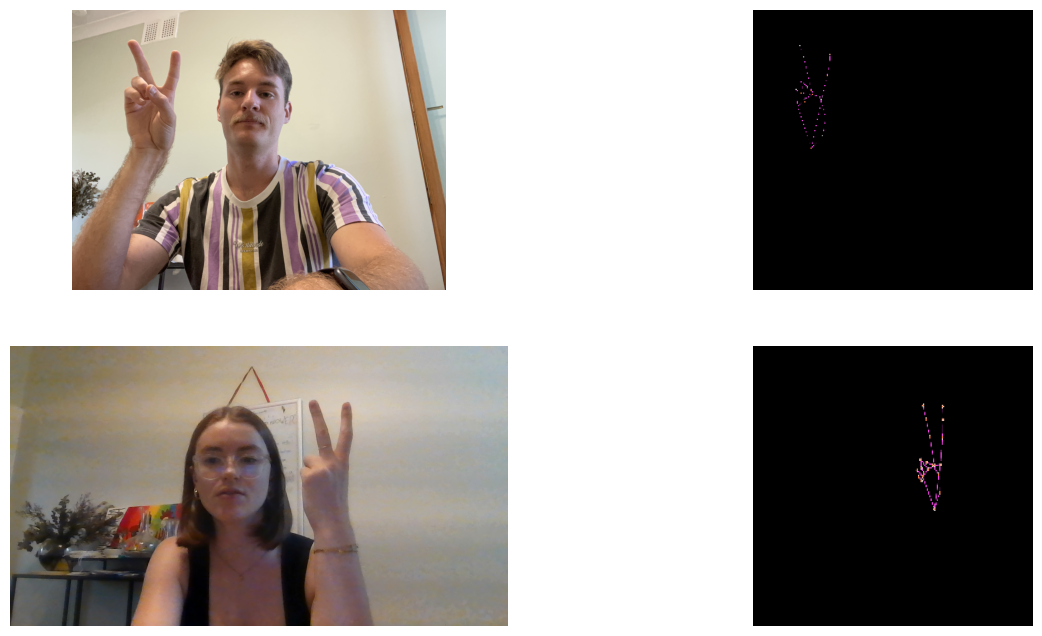


Categories for Image 1:
ID                             
Subject                    Luke
Date                 Apr 3 2025
Device                iPhone 12
Filename          Luke_2_43.JPG
Class                         2
Lighting                   Warm
Light level              Bright
Background            Not plain
Skin Tone                 White
Distance                 Medium
Orientation              Direct
Clothing                   Dark
Hand                      Right
Away from body              Yes
Name: 3713, dtype: object

Categories for Image 2:
ID                                  974
Subject                          Evelyn
Date                        Mar 20 2025
Device                 Dell XPS 15 9050
Filename                 Evelyn_2_7.jpg
Class                                 2
Lighting                           Warm
Light level                      Medium
Background        Somewhat/mostly plain
Skin Tone                         White
Distance                         Medium
Orie

In [ ]:
# Display example images pre and post processing

import tensorflow as tf
import matplotlib.pyplot as plt
import cv2
import numpy as np
import pandas as pd

# Redefine the training dataset creation to include filenames (if not already done)
# This is necessary to link the processed images back to the original filenames
training_with_filenames = tf.data.Dataset.from_tensor_slices((training_images.values, label_training, training_images.values))
training_with_filenames = training_with_filenames.map(
    lambda image_path, label, original_filename: (load_image_wrapper(image_path), label, original_filename),
    num_parallel_calls=tf.data.AUTOTUNE
)
training_with_filenames = training_with_filenames.batch(32).prefetch(tf.data.AUTOTUNE)

# Now iterate through the dataset to find the filenames of the two images
found_filenames = []
device1_filename = None
device2_filename = None

for images, labels, filenames_tensor in training_with_filenames:
    for image_tensor, label_tensor, filename_tensor in zip(tf.unstack(images), tf.unstack(labels), tf.unstack(filenames_tensor)):
        filename = filename_tensor.numpy().decode()

        spreadsheet_row = spreadsheet[spreadsheet['Filename'] == filename]

        if not spreadsheet_row.empty:
            current_class = spreadsheet_row['Class'].iloc[0]
            current_device = spreadsheet_row['Device'].iloc[0]

            if device1_filename is None:
                device1_filename = filename
                device1_class = current_class
                device1_device = current_device
                found_filenames.append(filename)

            elif current_class == device1_class and current_device != device1_device:
                device2_filename = filename
                found_filenames.append(filename)
                break

    if len(found_filenames) == 2:
        break

# If filenames are found, retrieve the processed images from the dataset
if len(found_filenames) == 2:
    image1_filename = found_filenames[0]
    image2_filename = found_filenames[1]

    found_processed_images = []
    found_processed_filenames = []

    # Iterate through the dataset again to find the processed images for the found filenames
    for images, labels, filenames_tensor in training_with_filenames:
        for image_tensor, label_tensor, filename_tensor in zip(tf.unstack(images), tf.unstack(labels), tf.unstack(filenames_tensor)):
            filename = filename_tensor.numpy().decode()

            if filename in found_filenames:
                found_processed_images.append(image_tensor.numpy())
                found_processed_filenames.append(filename)

                # If we've found both, stop
                if len(found_processed_images) == 2:
                    break
        if len(found_processed_images) == 2:
            break


    # Load the original images using OpenCV
    image_path_1_original = os.path.join(dataset_path, image1_filename)
    image_path_2_original = os.path.join(dataset_path, image2_filename)

    img1_original = cv2.imread(image_path_1_original)
    img2_original = cv2.imread(image_path_2_original)

    if img1_original is not None and img2_original is not None and len(found_processed_images) == 2:
        # Convert original images to RGB for matplotlib display
        img1_original_rgb = cv2.cvtColor(img1_original, cv2.COLOR_BGR2RGB)
        img2_original_rgb = cv2.cvtColor(img2_original, cv2.COLOR_BGR2RGB)

        # Find the corresponding processed images
        # The order in found_processed_images might not be the same as found_filenames
        processed_img1 = found_processed_images[found_processed_filenames.index(image1_filename)]
        processed_img2 = found_processed_images[found_processed_filenames.index(image2_filename)]


        plt.figure(figsize=(15, 8))

        # Plot Original Image 1
        plt.subplot(2, 2, 1)
        plt.imshow(img1_original_rgb)
        plt.axis('off')

        # Plot Processed Image 1 from TF Dataset
        plt.subplot(2, 2, 2)
        plt.imshow(processed_img1)
        plt.axis('off')

        # Plot Original Image 2
        plt.subplot(2, 2, 3)
        plt.imshow(img2_original_rgb)
        plt.axis('off')

        # Plot Processed Image 2 from TF Dataset
        plt.subplot(2, 2, 4)
        plt.imshow(processed_img2)
        plt.axis('off')


        plt.show()

        # Print categories for the found images
        print("\nCategories for Image 1:")
        print(spreadsheet[spreadsheet['Filename'] == image1_filename].iloc[0])

        print("\nCategories for Image 2:")
        print(spreadsheet[spreadsheet['Filename'] == image2_filename].iloc[0])

    else:
        print("Error loading images or could not find processed images.")

else:
    print("Could not find two images in the training dataset with the same subcategories except for 'Device'.")

# You can revert the training dataset back to the original definition if needed for training
training = tf.data.Dataset.from_tensor_slices((training_images.values, label_training))
training = training.map(lambda image_path, label: (load_image_wrapper(image_path), label), num_parallel_calls=tf.data.AUTOTUNE)
training = training.batch(32).prefetch(tf.data.AUTOTUNE)

# Remember to re-run the augmentation step if you are using it after this cell.

A. Surmenok, keras\_lr\_finder, GitHub repository. Available: https://github.com/surmenok/keras\_lr\_finder. Accessed: May 03, 2025.

In [ ]:
from matplotlib import pyplot as plt
import math
from keras.callbacks import LambdaCallback
import keras.backend as K
import numpy as np

import numpy as np

def set_value(x, value):
    value = np.asarray(value, dtype=x.dtype)  # Use x.dtype instead of x.dtype.name
    x.assign(value)

class LRFinder:
    """
    Plots the change of the loss function of a Keras model when the learning rate is exponentially increasing.
    See for details:
    https://towardsdatascience.com/estimating-optimal-learning-rate-for-a-deep-neural-network-ce32f2556ce0
    """

    def __init__(self, model):
        self.model = model
        self.losses = []
        self.lrs = []
        self.best_loss = 1e9

    def on_batch_end(self, batch, logs):
        # Log the learning rate
        lr = K.get_value(self.model.optimizer.learning_rate)
        self.lrs.append(lr)

        # Log the loss
        loss = logs['loss']
        self.losses.append(loss)

        # Check whether the loss got too large or NaN
        if batch > 5 and (math.isnan(loss) or loss > self.best_loss * 4):
            self.model.stop_training = True
            return

        if loss < self.best_loss:
            self.best_loss = loss

        # Increase the learning rate for the next batch
        lr *= self.lr_mult
        set_value(self.model.optimizer.learning_rate, lr)

    def find(self, x_train, y_train, start_lr, end_lr, batch_size=64, epochs=1, **kw_fit):
        # If x_train contains data for multiple inputs, use length of the first input.
        # Assumption: the first element in the list is single input; NOT a list of inputs.
        N = x_train[0].shape[0] if isinstance(x_train, list) else x_train.shape[0]

        # Compute number of batches and LR multiplier
        num_batches = epochs * N / batch_size
        self.lr_mult = (float(end_lr) / float(start_lr)) ** (float(1) / float(num_batches))
        # Save weights into a file
        initial_weights = self.model.get_weights()

        # Remember the original learning rate
        original_lr = K.get_value(self.model.optimizer.lr)

        # Set the initial learning rate
        K.set_value(self.model.optimizer.lr, start_lr)

        callback = LambdaCallback(on_batch_end=lambda batch, logs: self.on_batch_end(batch, logs))

        self.model.fit(x_train, y_train,
                       batch_size=batch_size, epochs=epochs,
                       callbacks=[callback],
                       **kw_fit)

        # Restore the weights to the state before model fitting
        self.model.set_weights(initial_weights)

        # Restore the original learning rate
        K.set_value(self.model.optimizer.lr, original_lr)

    def find_generator(self, generator, start_lr, end_lr, epochs=1, steps_per_epoch=None, **kw_fit):
        if steps_per_epoch is None:
            try:
                steps_per_epoch = len(generator)
            except (ValueError, NotImplementedError) as e:
                raise e('`steps_per_epoch=None` is only valid for a'
                        ' generator based on the '
                        '`keras.utils.Sequence`'
                        ' class. Please specify `steps_per_epoch` '
                        'or use the `keras.utils.Sequence` class.')
        self.lr_mult = (float(end_lr) / float(start_lr)) ** (float(1) / float(epochs * steps_per_epoch))

        # Save weights into a file
        initial_weights = self.model.get_weights()

        # Remember the original learning rate
        original_lr = K.get_value(self.model.optimizer.learning_rate)

        # Set the initial learning rate
        set_value(self.model.optimizer.learning_rate, start_lr)

        callback = LambdaCallback(on_batch_end=lambda batch,
                                                      logs: self.on_batch_end(batch, logs))

        self.model.fit(generator,
                                 epochs=epochs,
                                 steps_per_epoch=steps_per_epoch,
                                 callbacks=[callback],
                                 **kw_fit)

        # Restore the weights to the state before model fitting
        self.model.set_weights(initial_weights)

        # Restore the original learning rate
        set_value(self.model.optimizer.learning_rate, original_lr)

    def plot_loss(self, n_skip_beginning=10, n_skip_end=5, x_scale='log'):
        """
        Plots the loss.
        Parameters:
            n_skip_beginning - number of batches to skip on the left.
            n_skip_end - number of batches to skip on the right.
        """
        plt.ylabel("loss")
        plt.xlabel("learning rate (log scale)")
        plt.plot(self.lrs[n_skip_beginning:-n_skip_end], self.losses[n_skip_beginning:-n_skip_end])
        plt.xscale(x_scale)
        plt.show()

    def plot_loss_change(self, sma=1, n_skip_beginning=10, n_skip_end=5, y_lim=(-0.01, 0.01)):
        """
        Plots rate of change of the loss function.
        Parameters:
            sma - number of batches for simple moving average to smooth out the curve.
            n_skip_beginning - number of batches to skip on the left.
            n_skip_end - number of batches to skip on the right.
            y_lim - limits for the y axis.
        """
        derivatives = self.get_derivatives(sma)[n_skip_beginning:-n_skip_end]
        lrs = self.lrs[n_skip_beginning:-n_skip_end]
        plt.ylabel("rate of loss change")
        plt.xlabel("learning rate (log scale)")
        plt.plot(lrs, derivatives)
        plt.xscale('log')
        plt.ylim(y_lim)
        plt.show()

    def get_derivatives(self, sma):
        assert sma >= 1
        derivatives = [0] * sma
        for i in range(sma, len(self.lrs)):
            derivatives.append((self.losses[i] - self.losses[i - sma]) / sma)
        return derivatives

    def get_best_lr(self, sma, n_skip_beginning=10, n_skip_end=5):
        derivatives = self.get_derivatives(sma)
        best_der_idx = np.argmin(derivatives[n_skip_beginning:-n_skip_end])
        return self.lrs[n_skip_beginning:-n_skip_end][best_der_idx]

Epoch 1/10
456/456 ━━━━━━━━━━━━━━━━━━━━ 224s 413ms/step - accuracy: 0.0706 - loss: 3.8292
Epoch 2/10


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:151: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


456/456 ━━━━━━━━━━━━━━━━━━━━ 195s 425ms/step - accuracy: 0.0884 - loss: 3.7237
Epoch 3/10
456/456 ━━━━━━━━━━━━━━━━━━━━ 196s 428ms/step - accuracy: 0.1103 - loss: 3.5906
Epoch 4/10
456/456 ━━━━━━━━━━━━━━━━━━━━ 198s 433ms/step - accuracy: 0.2102 - loss: 3.2425
Epoch 5/10
456/456 ━━━━━━━━━━━━━━━━━━━━ 199s 434ms/step - accuracy: 0.3786 - loss: 2.7487
Epoch 6/10
456/456 ━━━━━━━━━━━━━━━━━━━━ 197s 431ms/step - accuracy: 0.5726 - loss: 2.1502
Epoch 7/10
456/456 ━━━━━━━━━━━━━━━━━━━━ 198s 431ms/step - accuracy: 0.7465 - loss: 1.6038
Epoch 8/10
456/456 ━━━━━━━━━━━━━━━━━━━━ 200s 437ms/step - accuracy: 0.8460 - loss: 1.2402
Epoch 9/10
456/456 ━━━━━━━━━━━━━━━━━━━━ 196s 428ms/step - accuracy: 0.8920 - loss: 1.0246
Epoch 10/10
456/456 ━━━━━━━━━━━━━━━━━━━━ 196s 427ms/step - accuracy: 0.9078 - loss: 0.9046


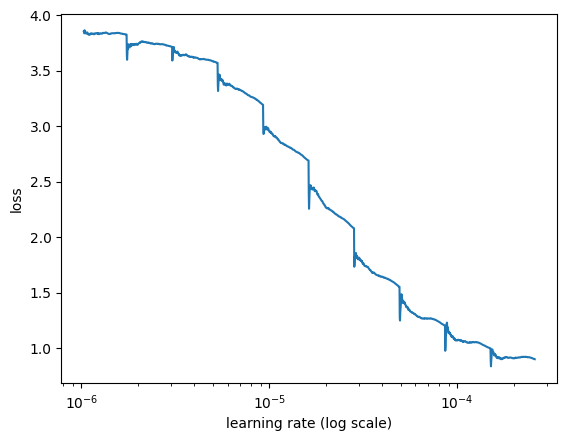

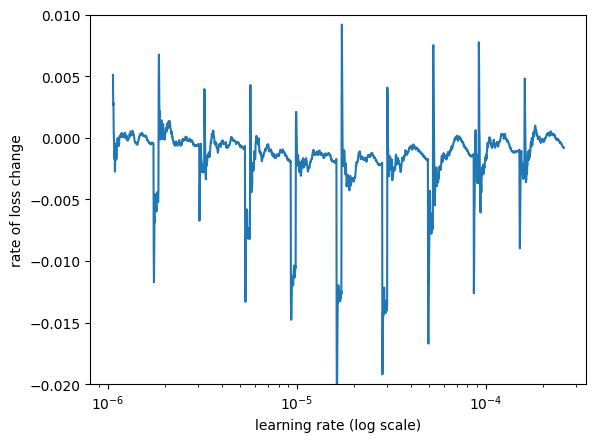

1.6287657e-05


In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import EarlyStopping

# Define input shape based on dataset
IMG_SHAPE = (224, 224, 3)

base_model = VGG16(weights="imagenet", include_top=False, input_shape=IMG_SHAPE)
# Unfreeze the last few convolutional layers
base_model.trainable = True

# Freeze most of the base model
for layer in base_model.layers[:-4]:
    layer.trainable = False

# Define model_no_var with its own base model
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.Dropout(0.5),
    layers.BatchNormalization(),
    layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.Dense(15, activation='softmax')
    ])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)

import numpy as np
K = tf.keras.backend

BATCH = 32
STEPS_PER_EPOCH = np.ceil(14585 / BATCH)
STEPS_PER_EPOCH = int(STEPS_PER_EPOCH)
lr_finder = LRFinder(model)
lr_finder.find_generator(training, start_lr=1e-6, end_lr=1, epochs=10,
                         steps_per_epoch=STEPS_PER_EPOCH)

lr_finder.plot_loss()
lr_finder.plot_loss_change(sma=20, n_skip_beginning=20, n_skip_end=5, y_lim=(-0.02, 0.01))

best_lr = lr_finder.get_best_lr(sma=20)

# Setting it as our model's LR through Keras Backend
set_value(model.optimizer.learning_rate, best_lr)
print(best_lr)

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras import layers, models, regularizers # Import regularizers here
from tensorflow.keras.callbacks import EarlyStopping

# Define input shape based on dataset
IMG_SHAPE = (224, 224, 3)

base_model = VGG16(weights="imagenet", include_top=False, input_shape=IMG_SHAPE)
base_model.trainable = True

# Freeze most of the base model
for layer in base_model.layers[:-4]:
    layer.trainable = False

# Define model with its own base model
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.Dropout(0.5),
    layers.BatchNormalization(),
    layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.Dense(15, activation='softmax')
    ])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)

optimizer = tf.keras.optimizers.Adam(learning_rate=float(best_lr))

model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)

es_1 = EarlyStopping(monitor='val_accuracy', mode='max', patience=10,  restore_best_weights=True)
model.fit(training, epochs=200, batch_size=32,validation_data=validation, callbacks=[es_1])

Epoch 1/200
184/184 ━━━━━━━━━━━━━━━━━━━━ 231s 1s/step - accuracy: 0.1159 - loss: 3.6148 - val_accuracy: 0.3216 - val_loss: 3.1919
Epoch 2/200
184/184 ━━━━━━━━━━━━━━━━━━━━ 224s 1s/step - accuracy: 0.3384 - loss: 2.7515 - val_accuracy: 0.5024 - val_loss: 2.4201
Epoch 3/200
184/184 ━━━━━━━━━━━━━━━━━━━━ 239s 1s/step - accuracy: 0.5411 - loss: 2.1809 - val_accuracy: 0.7184 - val_loss: 1.7970
Epoch 4/200
184/184 ━━━━━━━━━━━━━━━━━━━━ 238s 1s/step - accuracy: 0.6930 - loss: 1.7894 - val_accuracy: 0.8016 - val_loss: 1.4873
Epoch 5/200
184/184 ━━━━━━━━━━━━━━━━━━━━ 219s 1s/step - accuracy: 0.7689 - loss: 1.5375 - val_accuracy: 0.8400 - val_loss: 1.3341
Epoch 6/200
184/184 ━━━━━━━━━━━━━━━━━━━━ 219s 1s/step - accuracy: 0.8303 - loss: 1.3612 - val_accuracy: 0.8560 - val_loss: 1.2198
Epoch 7/200
184/184 ━━━━━━━━━━━━━━━━━━━━ 219s 1s/step - accuracy: 0.8598 - loss: 1.2259 - val_accuracy: 0.8784 - val_loss: 1.1321
Epoch 8/200
184/184 ━━━━━━━━━━━━━━━━━━━━ 220s 1s/step - accuracy: 0.8961 - loss: 1.1153 - 

In [ ]:
# Produce confusion matrix for included model tested on independent variable
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Produce confusion matrix for included model tested on independent variable
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Predict on the test set using the model
pred_1 = model.predict(testing, verbose=1)

# Get the predicted labels by taking the index of the maximum probability for each image
pred_1_labels = np.argmax(pred_1, axis=1)

# Get the true labels from the test set generator
pred_1_true = np.concatenate([y.numpy() for _, y in testing.unbatch()])

# Reshape into (N, 15) where N is inferred
pred_1_true = pred_1_true.reshape(-1, 15)

# Apply argmax to get class labels
pred_1_true = np.argmax(pred_1_true, axis=1)

# Generate the confusion matrix
cm_1 = confusion_matrix(pred_1_true, pred_1_labels)

20/20 ━━━━━━━━━━━━━━━━━━━━ 24s 1s/step


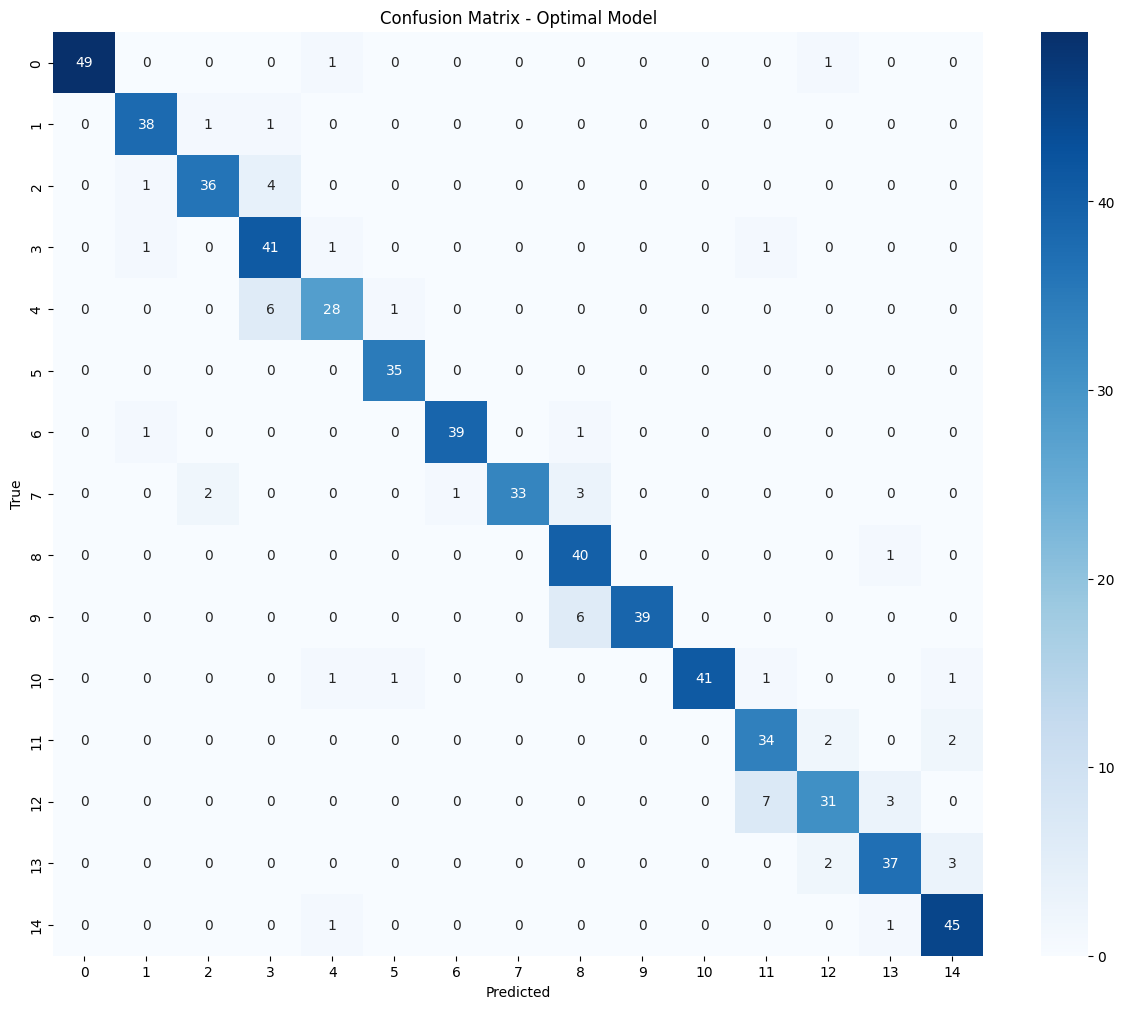

In [ ]:
# Define the confusion matrices and titles for plotting
confusion_matrices = [cm_1]
titles = ['Optimal Model']

# Generate the confusion matrix
cm_1 = confusion_matrix(pred_1_true, pred_1_labels)

# Plot the confusion matrix using seaborn
plt.figure(figsize=(15, 12))  # Adjust figure size as needed
sns.heatmap(cm_1, annot=True, fmt='d', cmap='Blues',
            xticklabels=[str(i) for i in range(cm_1.shape[1])],
            yticklabels=[str(i) for i in range(cm_1.shape[0])])
plt.title('Confusion Matrix - Optimal Model')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

In [ ]:
print("Optimal Model")
print(classification_report(pred_1_true, pred_1_labels))

Optimal Model
              precision    recall  f1-score   support

           0       1.00      0.96      0.98        51
           1       0.93      0.95      0.94        40
           2       0.92      0.88      0.90        41
           3       0.79      0.93      0.85        44
           4       0.88      0.80      0.84        35
           5       0.95      1.00      0.97        35
           6       0.97      0.95      0.96        41
           7       1.00      0.85      0.92        39
           8       0.80      0.98      0.88        41
           9       1.00      0.87      0.93        45
          10       1.00      0.91      0.95        45
          11       0.79      0.89      0.84        38
          12       0.86      0.76      0.81        41
          13       0.88      0.88      0.88        42
          14       0.88      0.96      0.92        47

    accuracy                           0.91       625
   macro avg       0.91      0.90      0.90       625
weighted avg

In [ ]:
import sys
import tensorflow as tf
import pandas as pd
import numpy as np
import mediapipe as mp
import gspread
import matplotlib
import seaborn
import sklearn

print(f"Python version: {sys.version}")
print(f"TensorFlow version: {tf.__version__}")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"Mediapipe version: {mp.__version__}")
print(f"gspread version: {gspread.__version__}")
print(f"Matplotlib version: {matplotlib.__version__}")
print(f"Seaborn version: {seaborn.__version__}")
print(f"Scikit-learn version: {sklearn.__version__}")

Python version: 3.11.12 (main, Apr  9 2025, 08:55:54) [GCC 11.4.0]
TensorFlow version: 2.18.0
Pandas version: 2.2.2
NumPy version: 2.0.2
Mediapipe version: 0.10.9
gspread version: 6.2.0
Matplotlib version: 3.10.0
Seaborn version: 0.13.2
Scikit-learn version: 1.6.1
